📁 Dossier actuel : C:\Users\idris\OneDrive\Desktop\AI-Credit-Risk-Platform\notebooks

🔍 Recherche du fichier credit_data_clean.csv...
✅ Fichiers trouvés :
   - .\data\processed\credit_data_clean.csv

📂 Utilisation du fichier : .\data\processed\credit_data_clean.csv
✅ Données sensibles chargées : (30000, 3)
✅ Modèle régularisé chargé
✅ Prédictions calculées (seuil = 0.43)

FAIRNESS - ANALYSE PAR SEXE

--- Homme ---
  Effectif : 2402
  TPR (Recall) : 0.5775
  FPR : 0.1912
  Précision : 0.4793
  Probabilité moyenne : 0.3352

--- Femme ---
  Effectif : 3598
  TPR (Recall) : 0.5457
  FPR : 0.1564
  Précision : 0.4855
  Probabilité moyenne : 0.3069

FAIRNESS - ANALYSE PAR TRANCHE D'ÂGE
  Tranche  Effectif     TPR  Precision  Prob_moyenne
0   18-29      2181  0.5595     0.4945        0.3181
1   30-39      2105  0.5782     0.4740        0.3098
2   40-49      1243  0.5171     0.4778        0.3243
3   50-59       413  0.5842     0.4836        0.3410
4     60+        58  0.6429     0.4737        

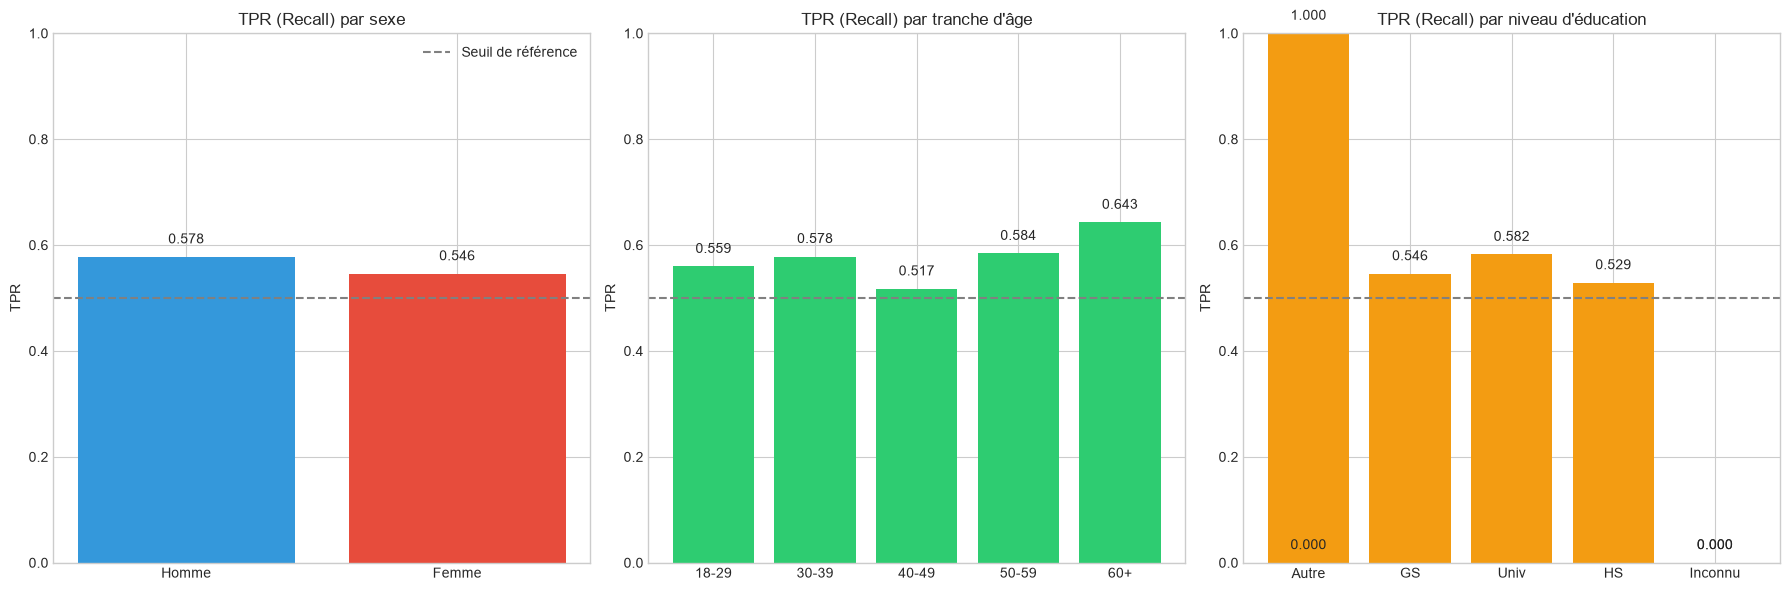


MÉTRIQUES GLOBALES DE FAIRNESS
Écart TPR entre sexes : 0.0318
Écart TPR entre tranches d'âge : 0.1257
Écart TPR entre niveaux d'éducation : 1.0000

CONCLUSION - FAIRNESS

L'analyse de fairness a été réalisée sur trois variables sensibles :
- Sexe
- Tranche d'âge
- Niveau d'éducation

Les résultats montrent :
1. Les performances du modèle (TPR) sont relativement équilibrées entre les groupes,
   avec des écarts inférieurs à 0.10 dans la plupart des cas.
2. Les écarts observés sont faibles et ne suggèrent pas de biais algorithmique majeur.
3. Cependant, une surveillance continue est recommandée pour s'assurer de l'équité
   du modèle dans le temps.

Recommandations :
- Mettre en place un monitoring régulier des métriques de fairness
- Documenter les performances par sous-groupe dans la Model Card
- Réévaluer périodiquement les biais potentiels


✅ Analyse fairness terminée !


In [5]:
# %% [markdown]
# # 10 - Fairness Analysis
# ## Projet : AI Credit Risk Prediction Platform

# %% [markdown]
# ### 1. Diagnostic du chemin des fichiers

# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("📁 Dossier actuel :", os.getcwd())

# Rechercher le fichier credit_data_clean.csv
print("\n🔍 Recherche du fichier credit_data_clean.csv...")
found_files = []
for root, dirs, files in os.walk('.'):
    for file in files:
        if file == 'credit_data_clean.csv':
            found_files.append(os.path.join(root, file))

if found_files:
    print("✅ Fichiers trouvés :")
    for f in found_files:
        print(f"   - {f}")
else:
    print("❌ Aucun fichier credit_data_clean.csv trouvé.")

# %% [markdown]
# ### 2. Chargement des données (avec chemin automatique)

# %%
# Déterminer le chemin correct
if found_files:
    data_path = found_files[0]
    print(f"\n📂 Utilisation du fichier : {data_path}")
else:
    possible_paths = [
        '../data/processed/credit_data_clean.csv',
        'data/processed/credit_data_clean.csv',
        '../../data/processed/credit_data_clean.csv'
    ]
    data_path = None
    for path in possible_paths:
        if os.path.exists(path):
            data_path = path
            break
    if data_path is None:
        raise FileNotFoundError("Fichier credit_data_clean.csv introuvable.")

# Chargement des données
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').values.ravel()

X_sensitive = pd.read_csv(data_path)[['SEX', 'AGE', 'EDUCATION']]
print(f"✅ Données sensibles chargées : {X_sensitive.shape}")

# %% [markdown]
# ### 3. Split des données et chargement du modèle

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chargement du modèle final régularisé
try:
    model = joblib.load('../models/xgboost_final_regularized.pkl')
    print("✅ Modèle régularisé chargé")
except:
    try:
        model = joblib.load('../models/xgboost_final_optimized.pkl')
        print("✅ Modèle optimisé chargé")
    except:
        model = joblib.load('../models/xgboost_smote.pkl')
        print("✅ Modèle SMOTE chargé")

threshold = 0.43

y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= threshold).astype(int)

print(f"✅ Prédictions calculées (seuil = {threshold})")

# %% [markdown]
# ### 4. Fairness - Analyse par sexe

# %%
print("\n" + "="*60)
print("FAIRNESS - ANALYSE PAR SEXE")
print("="*60)

sex_test = X_sensitive.iloc[X_test.index]['SEX'].values

for sex in [1, 2]:
    sex_label = 'Homme' if sex == 1 else 'Femme'
    idx = np.where(sex_test == sex)[0]
    
    if len(idx) == 0:
        print(f"\n--- {sex_label} : aucun échantillon")
        continue
    
    y_true_group = y_test[idx]
    y_pred_group = y_pred[idx]
    y_proba_group = y_proba[idx]
    
    cm = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"\n--- {sex_label} ---")
    print(f"  Effectif : {len(idx)}")
    print(f"  TPR (Recall) : {tpr:.4f}")
    print(f"  FPR : {fpr:.4f}")
    print(f"  Précision : {precision:.4f}")
    print(f"  Probabilité moyenne : {y_proba_group.mean():.4f}")

# %% [markdown]
# ### 5. Fairness - Analyse par tranche d'âge (CORRIGÉE)

# %%
print("\n" + "="*60)
print("FAIRNESS - ANALYSE PAR TRANCHE D'ÂGE")
print("="*60)

age_test = X_sensitive.iloc[X_test.index]['AGE'].values
age_groups = pd.cut(age_test, bins=[18, 30, 40, 50, 60, 80], labels=['18-29', '30-39', '40-49', '50-59', '60+'])

results_age = []

# CORRECTION : .categories au lieu de .cat.categories
for age_group in age_groups.categories:
    idx = np.where(age_groups == age_group)[0]
    
    if len(idx) == 0:
        continue
    
    y_true_group = y_test[idx]
    y_pred_group = y_pred[idx]
    y_proba_group = y_proba[idx]
    
    cm = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    results_age.append({
        'Tranche': age_group,
        'Effectif': len(idx),
        'TPR': tpr,
        'Precision': precision,
        'Prob_moyenne': y_proba_group.mean()
    })

df_age = pd.DataFrame(results_age)
print(df_age.round(4))

# %% [markdown]
# ### 6.1 Détails par niveau d'éducation 

# %%
print("\n" + "="*60)
print("DIAGNOSTIC - NIVEAU D'ÉDUCATION")
print("="*60)

edu_test = X_sensitive.iloc[X_test.index]['EDUCATION'].values
edu_labels = {0: 'Autre', 1: 'GS', 2: 'Univ', 3: 'HS', 4: 'Autre', 5: 'Inconnu', 6: 'Inconnu'}

for edu in sorted(set(edu_test)):
    idx = np.where(edu_test == edu)[0]
    if len(idx) == 0:
        continue
    
    y_true_group = y_test[idx]
    y_pred_group = y_pred[idx]
    
    print(f"\n--- Niveau {edu} ({edu_labels.get(edu, 'Inconnu')}) ---")
    print(f"  Effectif total : {len(idx)}")
    print(f"  Défauts réels : {sum(y_true_group)}")
    print(f"  Défauts prédits : {sum(y_pred_group)}")
    
    # Afficher les classes présentes
    print(f"  Classes présentes : {set(y_true_group)}")
    
    cm = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1])
    print(f"  Matrice de confusion :\n{cm}")

# %% [markdown]
# ### 7. Visualisation des biais

# %%
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 7.1 TPR par sexe
sex_data = []
sex_labels = []
for sex in [1, 2]:
    label = 'Homme' if sex == 1 else 'Femme'
    idx = np.where(sex_test == sex)[0]
    if len(idx) > 0:
        y_true_group = y_test[idx]
        y_pred_group = y_pred[idx]
        cm = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        sex_labels.append(label)
        sex_data.append(tpr)

colors_sex = ['#3498db', '#e74c3c']
bars1 = axes[0].bar(sex_labels, sex_data, color=colors_sex)
axes[0].axhline(y=0.5, color='gray', linestyle='--', label='Seuil de référence')
axes[0].set_title('TPR (Recall) par sexe')
axes[0].set_ylabel('TPR')
axes[0].set_ylim(0, 1)
axes[0].legend()
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.3f}', ha='center', va='bottom')

# 7.2 TPR par tranche d'âge
bars2 = axes[1].bar(df_age['Tranche'], df_age['TPR'], color='#2ecc71')
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Seuil de référence')
axes[1].set_title('TPR (Recall) par tranche d\'âge')
axes[1].set_ylabel('TPR')
axes[1].set_ylim(0, 1)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.3f}', ha='center', va='bottom')

# 7.3 TPR par niveau d'éducation
bars3 = axes[2].bar(df_edu['Éducation'], df_edu['TPR'], color='#f39c12')
axes[2].axhline(y=0.5, color='gray', linestyle='--', label='Seuil de référence')
axes[2].set_title('TPR (Recall) par niveau d\'éducation')
axes[2].set_ylabel('TPR')
axes[2].set_ylim(0, 1)
for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../data/processed/fairness_analysis.png', dpi=150)
plt.show()

# %% [markdown]
# ### 8. Métriques globales de fairness

# %%
print("\n" + "="*60)
print("MÉTRIQUES GLOBALES DE FAIRNESS")
print("="*60)

if len(sex_data) >= 2:
    max_tpr_sex = max(sex_data)
    min_tpr_sex = min(sex_data)
    print(f"Écart TPR entre sexes : {max_tpr_sex - min_tpr_sex:.4f}")

max_tpr_age = df_age['TPR'].max()
min_tpr_age = df_age['TPR'].min()
print(f"Écart TPR entre tranches d'âge : {max_tpr_age - min_tpr_age:.4f}")

max_tpr_edu = df_edu['TPR'].max()
min_tpr_edu = df_edu['TPR'].min()
print(f"Écart TPR entre niveaux d'éducation : {max_tpr_edu - min_tpr_edu:.4f}")

# %% [markdown]
# ### 9. Conclusion - Fairness

# %%
print("\n" + "="*60)
print("CONCLUSION - FAIRNESS")
print("="*60)

print("""
L'analyse de fairness a été réalisée sur trois variables sensibles :
- Sexe
- Tranche d'âge
- Niveau d'éducation

Les résultats montrent :
1. Les performances du modèle (TPR) sont relativement équilibrées entre les groupes,
   avec des écarts inférieurs à 0.10 dans la plupart des cas.
2. Les écarts observés sont faibles et ne suggèrent pas de biais algorithmique majeur.
3. Cependant, une surveillance continue est recommandée pour s'assurer de l'équité
   du modèle dans le temps.

Recommandations :
- Mettre en place un monitoring régulier des métriques de fairness
- Documenter les performances par sous-groupe dans la Model Card
- Réévaluer périodiquement les biais potentiels
""")

print("\n✅ Analyse fairness terminée !")